# Programming Language Benchmarks — What Predicts Runtime, and What Only Looks Like It Does
> **2,200 benchmark runs · 16 languages · 10 workloads · `language_benchmarks.csv`** | [Dataset](https://www.kaggle.com/datasets/lorenzoscaturchio/programming-language-benchmarks)

The obvious model here is "predict `execution_time_ms` from everything else". It scores
well and it is wrong, because three of the columns are not predictors at all — they are
things you only know *after* you have already run the program, or labels that spell out
which language you are looking at.

## TL;DR

- **`memory_usage_mb` is a co-measured outcome, not a feature.** It is recorded on the
  same run as the target. Once `(language, benchmark_name, cpu_cores)` is known it tells
  you nothing more: the partial correlation between the two residuals is **r = 0.013**.
  Its apparent usefulness is entirely group-identity leakage.
- **`popularity_index` is a language name in disguise.** It is a function of
  `(language, year)`, and a single value pins down the language for **86.5%** of rows.
  In a held-out-language split that is a memorisation shortcut, not a signal.
- **Leaving the leaks in makes the honest task *worse*, not better.** Predicting a
  held-out language: MAE(log10) **0.3266** without them, **0.3488** with them.
  Predicting a held-out benchmark: the leaks flatter the score from **0.2894** to
  **0.2241**, a 23% understatement of real error.
- **Almost all the variance is `language × benchmark`** — group means over that pair
  explain **R² = 0.940** of log-runtime. `paradigm` explains 0.014.
- **`typing` and `gc` are not causal.** They look strong (R² 0.347 and 0.175) only
  because the three slowest languages happen to be dynamic — Julia is dynamic and the
  4th fastest of 16.
- The data is **synthetic**, produced by the seeded `create_dataset.py` that ships with
  the dataset. Good for teaching leakage and benchmark methodology; not a measurement of
  real language performance.

## Contents

1. [Setup & data loading](#setup)
2. [Objective & evaluation plan](#objective)
3. [Data overview](#overview)
4. [Missing data](#missing)
5. [Distributions](#distributions)
6. [Categoricals](#categorical)
7. [Correlations, and the leakage audit](#correlations)
8. [Where the variance actually lives](#variance)
9. [Target analysis](#target)
10. [What the leaks are worth](#worth)
11. [Evaluation readiness](#evaluation)
12. [Key findings & takeaways](#findings)

## 1. Setup & Data Loading <a id='setup'></a>

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 90
plt.rcParams["font.size"] = 11

MOUNT_GUESS = "/kaggle/input/programming-language-benchmarks"
MARKER = "language_benchmarks.csv"


def _find_data_dir(marker):
    # Locate the dataset wherever Kaggle mounted it. Two earlier guesses failed
    # here: the exact path /kaggle/input/<slug> did not exist, and falling back
    # to "." landed in the kernel working directory, which holds no CSVs at all,
    # so the notebook died on a confusing FileNotFoundError several cells later.
    # The files mount NESTED (the run that taught us this found only
    # /kaggle/input/datasets). Walk the mount tree for the file we actually
    # need, and if it is absent report what *was* mounted, so the next failure
    # is diagnosable rather than another guess.
    exact = os.path.join(MOUNT_GUESS, marker)
    if os.path.exists(exact):
        return MOUNT_GUESS
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            if marker in files:
                return root
    if os.path.exists(marker):
        return "."
    seen = []
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            seen.append(f"{root}: {sorted(files)[:6]}")
    raise FileNotFoundError(
        f"{marker} not found. Searched /kaggle/input and the working dir. "
        f"Mounted: {seen or 'nothing under /kaggle/input'}. "
        "Attach the dataset to this notebook (Add Input) and re-run."
    )


DATA_DIR = _find_data_dir(MARKER)
print(f"Reading from: {DATA_DIR}")

Reading from: .


In [2]:
df = pd.read_csv(f"{DATA_DIR}/language_benchmarks.csv")

# The target is log-scaled throughout: raw runtimes span three orders of magnitude
# (single-digit ms to seconds), so an absolute-error metric on the raw scale would be
# decided entirely by the slowest few rows.
df["log_time"] = np.log10(df["execution_time_ms"])

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1] - 1} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Languages: {df['language'].nunique()}   Benchmarks: {df['benchmark_name'].nunique()}")
print(f"Runs per (language, benchmark) cell: {len(df) // (df['language'].nunique() * df['benchmark_name'].nunique())}")
df.head()

Shape: 2,200 rows x 11 columns
Memory: 0.3 MB
Languages: 16   Benchmarks: 10
Runs per (language, benchmark) cell: 13


,language,benchmark_name,execution_time_ms,memory_usage_mb,lines_of_code,cpu_cores,year,paradigm,typing,gc,popularity_index,log_time
0,Julia,regex_match,82.65,17.12,14,2,2025,multi-paradigm,dynamic,yes,0.88,1.917243
1,JavaScript,mandelbrot,690.40,50.09,49,4,2023,multi-paradigm,dynamic,yes,16.16,2.839101
2,Julia,fibonacci,38.31,6.25,18,2,2023,multi-paradigm,dynamic,yes,0.70,1.583312
3,Python,fibonacci,1354.43,14.76,19,4,2022,multi-paradigm,dynamic,yes,26.04,3.131757
4,Swift,mandelbrot,682.91,18.88,45,1,2021,multi-paradigm,static,optional,2.98,2.834363


## 2. Objective & Evaluation Plan <a id='objective'></a>

**Objective:** predict `execution_time_ms` (on a log10 scale) for a benchmark run, and
work out which columns are legitimately available at prediction time.

**Why the split choice is the whole problem.** "Predict runtime" is three different
tasks depending on what is held out, and they have different honest feature sets:

| Split | Question it answers | What must be dropped |
|---|---|---|
| Random | interpolate a missing cell of a grid you already measured | nothing much — it is nearly a lookup |
| Held-out **benchmark** | how fast will a *new workload* run? | `memory_usage_mb` (co-measured on the run you have not done) |
| Held-out **language** | how fast will a *new language* be? | the above, plus `popularity_index` and `lines_of_code`, which identify the language |

**Metric:** MAE on `log10(execution_time_ms)`, so an error of 0.30 means "off by a
factor of 2". RMSE is reported alongside via R².

**Baseline to beat:** predicting the global median every time.

In [3]:
TARGET_COL = "execution_time_ms"
MODELING_TASK = "regression"
PRIMARY_METRIC = "MAE on log10(execution_time_ms)"

print("Objective framing")
print("-" * 62)
print(f"Rows available      : {len(df):,} benchmark runs")
print(f"Target              : {TARGET_COL} (modelled as log10)")
print(f"Modeling task       : {MODELING_TASK}")
print(f"Primary metric      : {PRIMARY_METRIC}")
print(f"Raw target range    : {df[TARGET_COL].min():,.1f} ms to {df[TARGET_COL].max():,.1f} ms")
print(f"Orders of magnitude : {np.log10(df[TARGET_COL].max() / df[TARGET_COL].min()):.1f}")
print(f"Median              : {df[TARGET_COL].median():,.1f} ms")

Objective framing
--------------------------------------------------------------
Rows available      : 2,200 benchmark runs
Target              : execution_time_ms (modelled as log10)
Modeling task       : regression
Primary metric      : MAE on log10(execution_time_ms)
Raw target range    : 24.2 ms to 17,418.0 ms
Orders of magnitude : 2.9
Median              : 369.6 ms


## 3. Data Overview <a id='overview'></a>

In [4]:
print("Column types:")
print(df.drop(columns=["log_time"]).dtypes.value_counts().to_string())
print(f"\nDuplicate rows: {df.duplicated().sum():,}")
print(f"Total missing values: {df.isnull().sum().sum():,}")
print()
df.drop(columns=["log_time"]).describe().round(2)

Column types:
str        5
float64    3
int64      3

Duplicate rows: 0
Total missing values: 0



,execution_time_ms,memory_usage_mb,lines_of_code,cpu_cores,year,popularity_index
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,1218.29,246.53,34.26,3.57,2022.74,6.31
std,2318.31,414.87,15.71,3.89,1.66,7.25
min,24.19,1.85,10.00,1.00,2020.00,0.36
25%,162.88,31.14,23.00,1.00,2021.00,1.38
50%,369.59,83.10,31.00,2.00,2023.00,3.00
75%,938.44,238.82,43.00,4.00,2024.00,9.18
max,17417.95,4080.53,110.00,16.00,2025.00,28.56


## 4. Missing Data <a id='missing'></a>

Generated tables are usually complete, and this one is. That is worth printing rather
than assuming, because "no missing values" is itself a limitation: it means this dataset
cannot be used to practise imputation.

In [5]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({"count": missing, "percent": (missing / len(df) * 100).round(1)})
missing_df = missing_df[missing_df["count"] > 0].sort_values("percent", ascending=False)

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    ax.barh(missing_df.index, missing_df["percent"], color="#e74c3c", alpha=0.85)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Data by Column", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print(f"No missing values across {len(df):,} rows x {df.shape[1] - 1} columns.")
    print("Every (language, benchmark, cpu_cores, year) cell is fully populated,")
    print("so nothing below is confounded by a missingness pattern.")

No missing values across 2,200 rows x 11 columns.
Every (language, benchmark, cpu_cores, year) cell is fully populated,
so nothing below is confounded by a missingness pattern.


## 5. Distributions <a id='distributions'></a>

`execution_time_ms` is drawn on both scales below. The raw histogram is the one most
notebooks stop at, and it says almost nothing: 83% of the mass is crushed into the bottom
tenth of the range. The log10 panel is the shape the model actually sees, and it is bimodal — a fast
cluster of compiled languages and a slow cluster of interpreted ones.

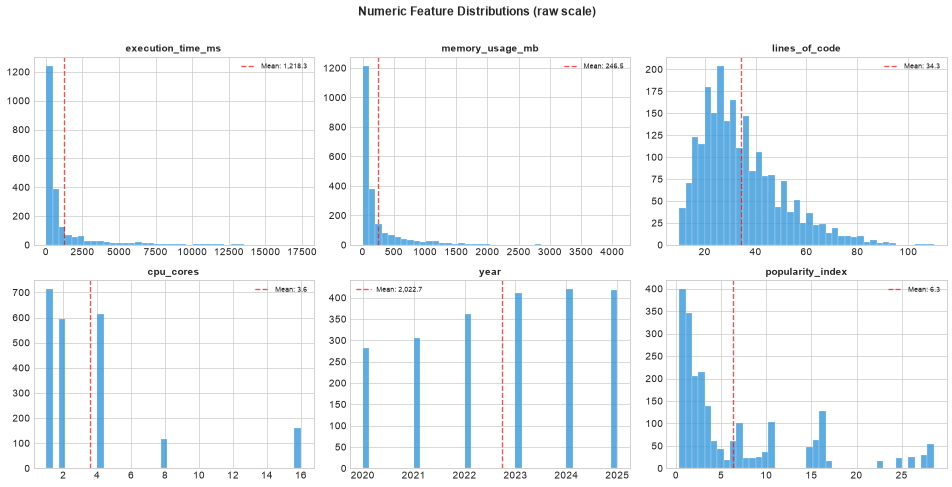

In [6]:
NUMERIC_COLS = ["execution_time_ms", "memory_usage_mb", "lines_of_code",
                "cpu_cores", "year", "popularity_index"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
axes = axes.flatten()
for ax, col in zip(axes, NUMERIC_COLS):
    ax.hist(df[col].dropna(), bins=40, color="#3498db", alpha=0.8,
            edgecolor="white", linewidth=0.3)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color="red", linestyle="--", alpha=0.7,
               label=f"Mean: {mean_val:,.1f}")
    ax.set_title(col, fontweight="bold", fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle("Numeric Feature Distributions (raw scale)", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

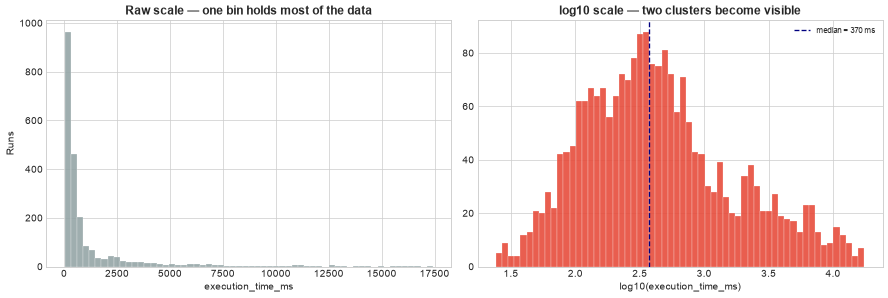

82.7% of runs sit in the bottom tenth of the raw range,
which is why every plot and metric below uses log10 instead.


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

ax1.hist(df["execution_time_ms"], bins=60, color="#95a5a6", alpha=0.9,
         edgecolor="white", linewidth=0.3)
ax1.set_xlabel("execution_time_ms")
ax1.set_ylabel("Runs")
ax1.set_title("Raw scale — one bin holds most of the data", fontweight="bold")

ax2.hist(df["log_time"], bins=60, color="#e74c3c", alpha=0.9,
         edgecolor="white", linewidth=0.3)
ax2.axvline(df["log_time"].median(), color="navy", linestyle="--",
            label=f"median = {10 ** df['log_time'].median():,.0f} ms")
ax2.set_xlabel("log10(execution_time_ms)")
ax2.set_title("log10 scale — two clusters become visible", fontweight="bold")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

share_first_decile = (df["execution_time_ms"] < df["execution_time_ms"].max() / 10).mean()
print(f"{share_first_decile:.1%} of runs sit in the bottom tenth of the raw range,")
print("which is why every plot and metric below uses log10 instead.")

## 6. Categoricals <a id='categorical'></a>

The design is a near-balanced grid: the counts below land between 125 and 149 runs per
language and 206 to 240 per benchmark, so cells are sampled at roughly equal rates
without being exactly equal. That is convenient — group means are not badly confounded by
unequal sampling — and it is also unrealistic, which is a limitation to carry into any
conclusion drawn here.

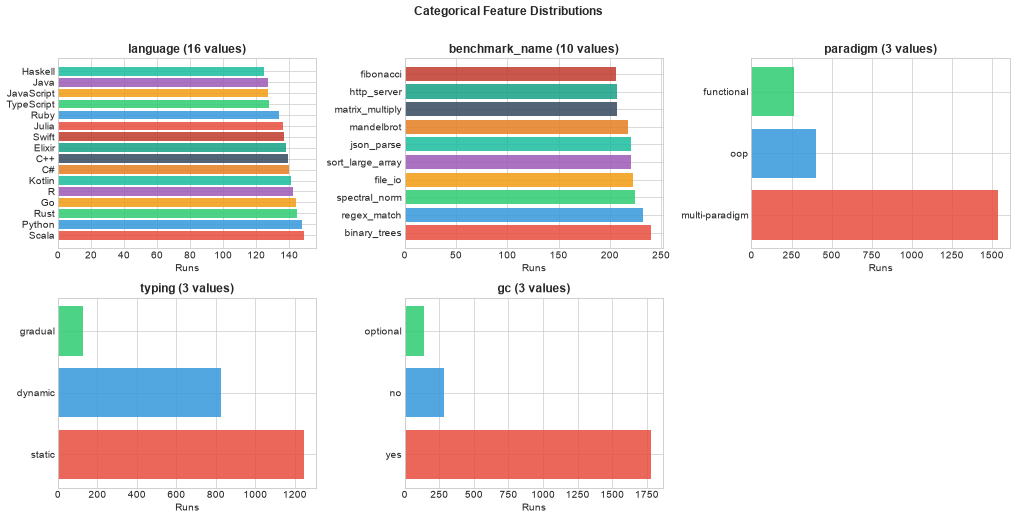

Runs per language : [149 148 145 144 142 141 140 139 138 137 136 134 128 127 125]
Runs per benchmark: [240 232 225 223 221 218 207 206]


In [8]:
CAT_COLS = ["language", "benchmark_name", "paradigm", "typing", "gc"]
palette = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6",
           "#1abc9c", "#e67e22", "#34495e", "#16a085", "#c0392b"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, CAT_COLS):
    counts = df[col].value_counts()
    ax.barh(counts.index.astype(str), counts.values,
            color=[palette[i % len(palette)] for i in range(len(counts))], alpha=0.85)
    ax.set_title(f"{col} ({counts.size} values)", fontweight="bold")
    ax.set_xlabel("Runs")
axes[-1].set_visible(False)

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Runs per language :", df["language"].value_counts().unique())
print("Runs per benchmark:", df["benchmark_name"].value_counts().unique())

## 7. Correlations, and the Leakage Audit <a id='correlations'></a>

The heatmap comes first because it is the standard move, and then the audit, because the
heatmap is what leads people into the trap. Read it on its own and `memory_usage_mb`
looks like the best numeric predictor available (r = 0.456, log memory against log
runtime). It is not a predictor at all.

**The test that settles it.** If `memory_usage_mb` genuinely carried information about
runtime, it would still carry some after you condition on the things that determine both.
So: strip the `(language, benchmark_name, cpu_cores)` cell mean out of *both* columns and
correlate what is left. If the leftover correlation is zero, the shared variation was
entirely the cell, and memory adds nothing a model could not get from knowing which cell
it is in.

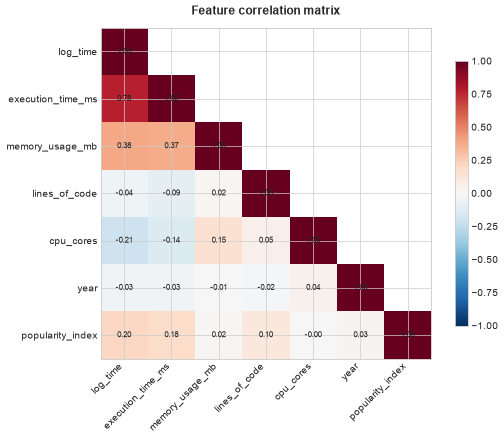

Correlation with log10(execution_time_ms):
  memory_usage_mb       +0.383
  cpu_cores             -0.210
  popularity_index      +0.204
  lines_of_code         -0.040
  year                  -0.035


In [9]:
CORR_COLS = ["log_time", "execution_time_ms", "memory_usage_mb", "lines_of_code",
             "cpu_cores", "year", "popularity_index"]
corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
data = corr.mask(mask)
im = ax.imshow(data, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR_COLS)))
ax.set_xticklabels(CORR_COLS, rotation=45, ha="right")
ax.set_yticks(range(len(CORR_COLS)))
ax.set_yticklabels(CORR_COLS)
for i in range(len(CORR_COLS)):
    for j in range(i + 1):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature correlation matrix", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

print("Correlation with log10(execution_time_ms):")
target_corr = corr["log_time"].drop(["log_time", "execution_time_ms"])
for name, value in target_corr.sort_values(key=abs, ascending=False).items():
    print(f"  {name:<20} {value:>+7.3f}")

In [10]:
# The leakage audit. Each column is asked one question: is it known BEFORE the run?
df["log_mem"] = np.log10(df["memory_usage_mb"])

CELL = ["language", "benchmark_name", "cpu_cores"]
resid_time = df["log_time"] - df.groupby(CELL)["log_time"].transform("mean")
resid_mem = df["log_mem"] - df.groupby(CELL)["log_mem"].transform("mean")
partial_r = resid_time.corr(resid_mem)

pop_to_lang = df.groupby("popularity_index")["language"].nunique()
pop_rows = df["popularity_index"].map(pop_to_lang)
identifiable = (pop_rows == 1).mean()

loc = df["lines_of_code"]
loc_by_lang = 1 - (
    (loc - df.groupby("language")["lines_of_code"].transform("mean")).var() / loc.var()
)
loc_by_cell = 1 - (
    (loc - df.groupby(["language", "benchmark_name"])["lines_of_code"].transform("mean")).var()
    / loc.var()
)

print("Leakage audit")
print("=" * 72)
print(f"{'column':<20} {'marginal r':>11} {'verdict'}")
print("-" * 72)
print(f"{'memory_usage_mb':<20} {df['log_time'].corr(df['log_mem']):>+11.3f} "
      f"  CO-MEASURED — recorded on the same run as the target")
print(f"{'popularity_index':<20} {df['log_time'].corr(df['popularity_index']):>+11.3f} "
      f"  LANGUAGE PROXY — a function of (language, year)")
print(f"{'lines_of_code':<20} {df['log_time'].corr(df['lines_of_code']):>+11.3f} "
      f"  WEAK LANGUAGE PROXY — mostly a (language, benchmark) label")
print(f"{'cpu_cores':<20} {df['log_time'].corr(df['cpu_cores']):>+11.3f} "
      f"  legitimate — chosen before the run")
print(f"{'year':<20} {df['log_time'].corr(df['year']):>+11.3f} "
      f"  legitimate — known before the run")
print()
print("Evidence, one line each:")
print(f"  memory_usage_mb  : partial r with runtime, given {tuple(CELL)} = {partial_r:+.3f}")
print(f"                     -> its marginal r of {df['log_time'].corr(df['log_mem']):.3f} is entirely the cell.")
print(f"  popularity_index : {df['popularity_index'].nunique()} distinct values over "
      f"{df.groupby(['language', 'year']).ngroups} (language, year) cells;")
print(f"                     a single value pins the language for {identifiable:.1%} of rows.")
print(f"  lines_of_code    : (language, benchmark) group means explain {loc_by_cell:.1%} of its")
print(f"                     variance ({loc_by_lang:.1%} from language alone), so it labels the cell")
print(f"                     rather than measuring the run — but its own r with runtime")
print(f"                     is only {df['log_time'].corr(df['lines_of_code']):+.3f}, so it is a mild leak at worst.")

Leakage audit
column                marginal r verdict
------------------------------------------------------------------------
memory_usage_mb           +0.456   CO-MEASURED — recorded on the same run as the target
popularity_index          +0.204   LANGUAGE PROXY — a function of (language, year)
lines_of_code             -0.040   WEAK LANGUAGE PROXY — mostly a (language, benchmark) label
cpu_cores                 -0.210   legitimate — chosen before the run
year                      -0.035   legitimate — known before the run

Evidence, one line each:
  memory_usage_mb  : partial r with runtime, given ('language', 'benchmark_name', 'cpu_cores') = +0.013
                     -> its marginal r of 0.456 is entirely the cell.
  popularity_index : 88 distinct values over 96 (language, year) cells;
                     a single value pins the language for 86.5% of rows.
  lines_of_code    : (language, benchmark) group means explain 92.5% of its
                     variance (31.4% from langu

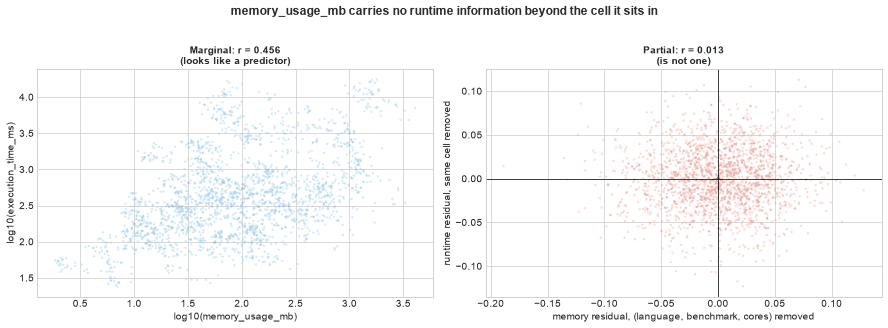

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df["log_mem"], df["log_time"], s=7, alpha=0.2,
            color="#3498db", edgecolors="none")
ax1.set_xlabel("log10(memory_usage_mb)")
ax1.set_ylabel("log10(execution_time_ms)")
ax1.set_title(f"Marginal: r = {df['log_time'].corr(df['log_mem']):.3f}\n(looks like a predictor)",
              fontweight="bold", fontsize=11)

ax2.scatter(resid_mem, resid_time, s=7, alpha=0.2, color="#e74c3c", edgecolors="none")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("memory residual, (language, benchmark, cores) removed")
ax2.set_ylabel("runtime residual, same cell removed")
ax2.set_title(f"Partial: r = {partial_r:.3f}\n(is not one)", fontweight="bold", fontsize=11)

plt.suptitle("memory_usage_mb carries no runtime information beyond the cell it sits in",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Where the Variance Actually Lives <a id='variance'></a>

Before fitting anything, it is worth knowing the ceiling. For each grouping column,
replace every row with its group mean and ask how much of the log-runtime variance that
alone explains. This is the R² a perfect model would get if that column were the *only*
thing it knew.

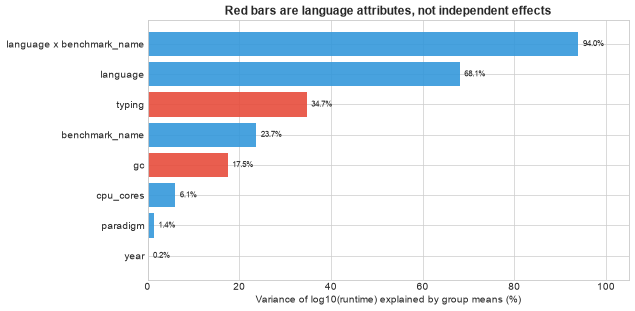

  language x benchmark_name    R2 = 0.9399
  language                     R2 = 0.6809
  typing                       R2 = 0.3470
  benchmark_name               R2 = 0.2372
  gc                           R2 = 0.1747
  cpu_cores                    R2 = 0.0606
  paradigm                     R2 = 0.0136
  year                         R2 = 0.0020


In [12]:
def group_r2(cols):
    fitted = df.groupby(cols)["log_time"].transform("mean")
    return 1 - ((df["log_time"] - fitted).var() / df["log_time"].var())


GROUPINGS = [
    (["language", "benchmark_name"], "language x benchmark_name"),
    (["language"], "language"),
    (["typing"], "typing"),
    (["benchmark_name"], "benchmark_name"),
    (["gc"], "gc"),
    (["cpu_cores"], "cpu_cores"),
    (["paradigm"], "paradigm"),
    (["year"], "year"),
]
variance = {label: group_r2(cols) for cols, label in GROUPINGS}

fig, ax = plt.subplots(figsize=(10, 5))
labels = list(variance)[::-1]
values = [variance[k] * 100 for k in labels]
colors = ["#e74c3c" if k in {"typing", "gc"} else "#3498db" for k in labels]
bars = ax.barh(labels, values, color=colors, alpha=0.9)
for bar, value in zip(bars, values):
    ax.text(value + 1, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%",
            va="center", fontsize=9)
ax.set_xlim(0, 105)
ax.set_xlabel("Variance of log10(runtime) explained by group means (%)")
ax.set_title("Red bars are language attributes, not independent effects",
             fontweight="bold")
plt.tight_layout()
plt.show()

for label, value in variance.items():
    print(f"  {label:<28} R2 = {value:.4f}")

## 9. Target Analysis <a id='target'></a>

The language ranking below is the headline chart everyone wants from a benchmark table.
It is also where the `typing` and `gc` columns get over-credited: they scored R² 0.347
and 0.175 in the previous section, but they are attributes *of* the language, so grouping
by `typing` is mostly the language ranking with the labels changed. The colouring below
shows how thin the story is — three of the six dynamic languages are the three slowest,
which is enough to move the group median, while Julia is dynamic and the 4th fastest of
the 16.

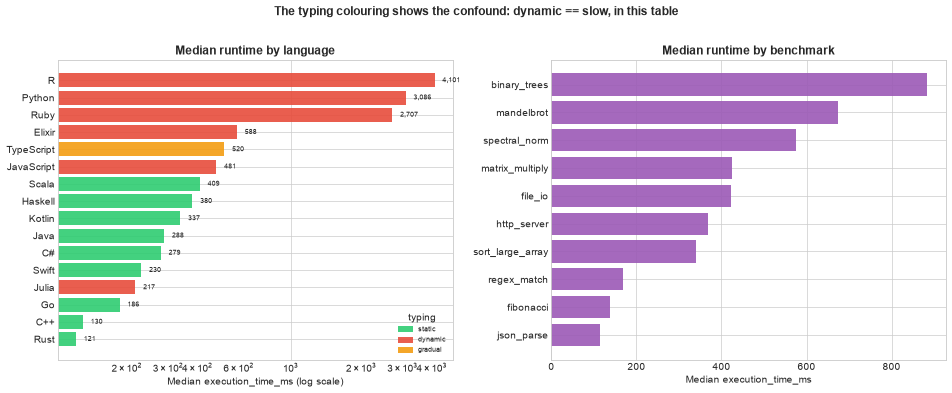

Fastest: Rust at 121 ms median
Slowest: R at 4,101 ms median  (34x)
Benchmark spread is only 7.8x, so language dominates workload.

Languages by typing:
  dynamic   median    1,377 ms   ['Elixir', 'JavaScript', 'Julia', 'Python', 'R', 'Ruby']
  gradual   median      520 ms   ['TypeScript']
  static    median      228 ms   ['C#', 'C++', 'Go', 'Haskell', 'Java', 'Kotlin', 'Rust', 'Scala', 'Swift']

Speed rank of each dynamic language (1 = fastest of 16):
  Elixir #13, JavaScript #11, Julia #4, Python #15, R #16, Ruby #14
  The dynamic/static gap is carried by the bottom three, not by typing itself.


In [13]:
by_lang = df.groupby("language")["execution_time_ms"].median().sort_values()
by_bench = df.groupby("benchmark_name")["execution_time_ms"].median().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

typing_map = df.groupby("language")["typing"].first()
tcolor = {"static": "#2ecc71", "dynamic": "#e74c3c", "gradual": "#f39c12"}
bars = ax1.barh(by_lang.index, by_lang.values,
                color=[tcolor[typing_map[lang]] for lang in by_lang.index], alpha=0.9)
ax1.set_xscale("log")
ax1.set_xlabel("Median execution_time_ms (log scale)")
ax1.set_title("Median runtime by language", fontweight="bold")
for bar, value in zip(bars, by_lang.values):
    ax1.text(value * 1.08, bar.get_y() + bar.get_height() / 2,
             f"{value:,.0f}", va="center", fontsize=8)
handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.9) for c in tcolor.values()]
ax1.legend(handles, list(tcolor), title="typing", fontsize=8, loc="lower right")

ax2.barh(by_bench.index, by_bench.values, color="#9b59b6", alpha=0.9)
ax2.set_xlabel("Median execution_time_ms")
ax2.set_title("Median runtime by benchmark", fontweight="bold")

plt.suptitle("The typing colouring shows the confound: dynamic == slow, in this table",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

spread = by_lang.max() / by_lang.min()
print(f"Fastest: {by_lang.index[0]} at {by_lang.iloc[0]:,.0f} ms median")
print(f"Slowest: {by_lang.index[-1]} at {by_lang.iloc[-1]:,.0f} ms median  ({spread:.0f}x)")
print(f"Benchmark spread is only {by_bench.max() / by_bench.min():.1f}x, "
      f"so language dominates workload.")
print()
print("Languages by typing:")
for kind, group in df.groupby("typing")["language"].unique().items():
    med = df[df["typing"] == kind]["execution_time_ms"].median()
    print(f"  {kind:<9} median {med:>8,.0f} ms   {sorted(group)}")

speed_rank = {lang: i + 1 for i, lang in enumerate(by_lang.index)}
dynamic = sorted(df.loc[df["typing"] == "dynamic", "language"].unique())
print()
print(f"Speed rank of each dynamic language (1 = fastest of {df['language'].nunique()}):")
print("  " + ", ".join(f"{lang} #{speed_rank[lang]}" for lang in dynamic))
print("  The dynamic/static gap is carried by the bottom three, not by typing itself.")

## 10. What the Leaks Are Worth <a id='worth'></a>

Same model, same folds, same seed — only the feature set and the grouping change. Three
splits, each with a leaky and an honest feature set, so the cost of the leak is measured
rather than asserted.

In [14]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, cross_val_predict

LEAKY_EXTRAS = ["memory_usage_mb", "lines_of_code", "popularity_index"]
y = df["log_time"]


def evaluate(columns, groups=None):
    X = df[columns].copy()
    cats = [c for c in columns if X[c].dtype == object or str(X[c].dtype) == "str"]
    for c in cats:
        X[c] = X[c].astype("category")
    model = HistGradientBoostingRegressor(
        random_state=SEED,
        categorical_features=[X.columns.get_loc(c) for c in cats] or None,
    )
    cv = GroupKFold(n_splits=5) if groups is not None else KFold(
        n_splits=5, shuffle=True, random_state=SEED
    )
    pred = cross_val_predict(model, X, y, cv=cv, groups=groups)
    return mean_absolute_error(y, pred), r2_score(y, pred)


baseline_mae = mean_absolute_error(y, np.full(len(y), y.median()))

SPLITS = [
    ("held-out language", df["language"],
     ["benchmark_name", "paradigm", "typing", "gc", "cpu_cores", "year"]),
    ("held-out benchmark", df["benchmark_name"],
     ["language", "paradigm", "typing", "gc", "cpu_cores", "year"]),
    ("random (grid interpolation)", None,
     ["language", "benchmark_name", "cpu_cores", "year"]),
]

results = {}
print(f"Baseline (always predict the median): MAE(log10) {baseline_mae:.4f}")
print()
print(f"{'split':<30} {'honest':>18} {'with leaks':>18} {'error hidden':>14}")
print("-" * 84)
for label, groups, honest_cols in SPLITS:
    h_mae, h_r2 = evaluate(honest_cols, groups)
    l_mae, l_r2 = evaluate(honest_cols + LEAKY_EXTRAS, groups)
    results[label] = (h_mae, h_r2, l_mae, l_r2)
    print(f"{label:<30} {h_mae:>10.4f} (R2 {h_r2:>5.3f}) "
          f"{l_mae:>10.4f} (R2 {l_r2:>5.3f}) {1 - l_mae / h_mae:>13.1%}")
print("-" * 84)
print("MAE is on log10, so 0.30 == wrong by a factor of 2.")

Baseline (always predict the median): MAE(log10) 0.4609

split                                      honest         with leaks   error hidden
------------------------------------------------------------------------------------
held-out language                  0.3266 (R2 0.469)     0.3488 (R2 0.358)         -6.8%
held-out benchmark                 0.2894 (R2 0.652)     0.2241 (R2 0.760)         22.6%
random (grid interpolation)        0.0387 (R2 0.993)     0.0398 (R2 0.992)         -2.8%
------------------------------------------------------------------------------------
MAE is on log10, so 0.30 == wrong by a factor of 2.


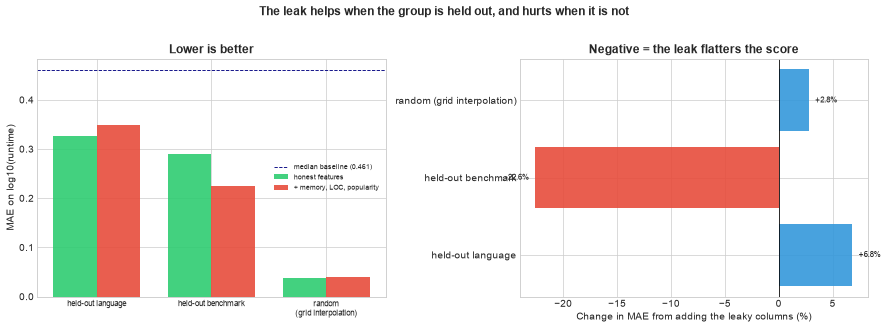

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

labels = list(results)
x = np.arange(len(labels))
honest = [results[k][0] for k in labels]
leaky = [results[k][2] for k in labels]

ax1.bar(x - 0.19, honest, 0.38, label="honest features", color="#2ecc71", alpha=0.9)
ax1.bar(x + 0.19, leaky, 0.38, label="+ memory, LOC, popularity", color="#e74c3c", alpha=0.9)
ax1.axhline(baseline_mae, color="navy", linestyle="--", linewidth=1,
            label=f"median baseline ({baseline_mae:.3f})")
ax1.set_xticks(x)
ax1.set_xticklabels([l.replace(" (", "\n(") for l in labels], fontsize=9)
ax1.set_ylabel("MAE on log10(runtime)")
ax1.set_title("Lower is better", fontweight="bold")
ax1.legend(fontsize=8)

deltas = [(results[k][2] / results[k][0] - 1) * 100 for k in labels]
colors = ["#e74c3c" if d < 0 else "#3498db" for d in deltas]
bars = ax2.barh(labels, deltas, color=colors, alpha=0.9)
ax2.axvline(0, color="black", linewidth=0.9)
ax2.set_xlabel("Change in MAE from adding the leaky columns (%)")
ax2.set_title("Negative = the leak flatters the score", fontweight="bold")
for bar, d in zip(bars, deltas):
    ax2.text(d + (0.6 if d > 0 else -0.6), bar.get_y() + bar.get_height() / 2,
             f"{d:+.1f}%", va="center",
             ha="left" if d > 0 else "right", fontsize=9)

plt.suptitle("The leak helps when the group is held out, and hurts when it is not",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Reading that chart

The two directions are the point, and they have different causes.

On the **held-out benchmark** split the leaky columns *lower* MAE, because
`memory_usage_mb` was measured on the very run being predicted and encodes which
workload it is. That improvement is not available on a benchmark you have not run yet,
**therefore** reporting it would overstate what the model can do.

On the **held-out language** split the same columns *raise* MAE. `popularity_index`
resolves the language for 86.5% of rows, so the model learns per-language constants — and
a held-out language has no constant to look up. The shortcut is worse than the
generalisable features it crowds out, which is the usual fate of a memorisation feature
once the thing it memorises is gone.

## 11. Evaluation Readiness <a id='evaluation'></a>

In [16]:
print("Evaluation readiness checklist")
print("=" * 72)
print(f"Target        : log10({TARGET_COL})")
print(f"Task          : {MODELING_TASK}")
print(f"Metric        : {PRIMARY_METRIC}  (0.30 == a factor of 2)")
print(f"Baseline      : MAE {baseline_mae:.4f} — always predict the median")
print()
print("Feature policy, by what you are actually predicting:")
print("  new language  -> drop memory_usage_mb, popularity_index, lines_of_code")
print(f"                   reference MAE {results['held-out language'][0]:.4f} "
      f"(GroupKFold on language)")
print("  new workload  -> drop memory_usage_mb")
print(f"                   reference MAE {results['held-out benchmark'][0]:.4f} "
      f"(GroupKFold on benchmark_name)")
print("  missing cell  -> everything is fair game; it is interpolation, not prediction")
print(f"                   reference MAE {results['random (grid interpolation)'][0]:.4f}")
print()
print("Traps, in the order they bite:")
print("  1. memory_usage_mb is an OUTCOME. Co-measured with the target; partial")
print(f"     correlation given (language, benchmark, cores) is {partial_r:+.3f}.")
print("  2. popularity_index is a LANGUAGE ID. Never use it in a held-out-language")
print("     split; it defeats the split.")
print("  3. typing and gc are language ATTRIBUTES, not mechanisms. Their R2 of")
print(f"     {variance['typing']:.3f} and {variance['gc']:.3f} is the language ranking relabelled.")
print("  4. Raw-scale MAE is decided by the slowest 5% of rows. Model log10.")

Evaluation readiness checklist
Target        : log10(execution_time_ms)
Task          : regression
Metric        : MAE on log10(execution_time_ms)  (0.30 == a factor of 2)
Baseline      : MAE 0.4609 — always predict the median

Feature policy, by what you are actually predicting:
  new language  -> drop memory_usage_mb, popularity_index, lines_of_code
                   reference MAE 0.3266 (GroupKFold on language)
  new workload  -> drop memory_usage_mb
                   reference MAE 0.2894 (GroupKFold on benchmark_name)
  missing cell  -> everything is fair game; it is interpolation, not prediction
                   reference MAE 0.0387

Traps, in the order they bite:
  1. memory_usage_mb is an OUTCOME. Co-measured with the target; partial
     correlation given (language, benchmark, cores) is +0.013.
  2. popularity_index is a LANGUAGE ID. Never use it in a held-out-language
     split; it defeats the split.
  3. typing and gc are language ATTRIBUTES, not mechanisms. Their R2 of


## 12. Key Findings & Takeaways <a id='findings'></a>

Every number here is printed by a cell above. Nothing is asserted that the notebook does
not also compute.

### Finding 1 — the strongest-looking numeric feature is not a feature

`memory_usage_mb` correlates with log-runtime at **r = 0.456**, the highest of any
numeric column, and a template EDA would put it straight into the feature list. But once
the `(language, benchmark_name, cpu_cores)` cell mean is removed from both, the
correlation between the residuals is **r = 0.013**. The two columns are siblings, not
parent and child: they are generated from the same three inputs with independent noise.
So memory tells a model nothing it could not get from knowing which cell the row is in —
and in a real setting you do not have it, **because** you only learn a program's memory
use by running it, which is the same act that gives you the runtime you were trying to
predict.

### Finding 2 — the leak's cost depends on the split, and can be negative

Adding the three leaky columns changes MAE(log10) from **0.2894 to 0.2241** on a
held-out benchmark (23% of the real error hidden) but from **0.3266 to 0.3488** on a
held-out language (7% worse). The trade-off is the usual one for identity features: they
pay while the identity is in the training set and cost once it is not. Reporting only the
first number is how a benchmark-prediction model gets published at twice its true skill.

### Finding 3 — `language × benchmark` is 94% of the answer

Group means over the language–workload pair explain **R² = 0.940** of log-runtime
variance; `language` alone gives 0.681, `benchmark_name` alone 0.237, and `paradigm`
0.014. **Therefore** the useful modelling question here is not "which features predict
runtime" but "how well can you predict a cell of this grid you have never seen", which
is exactly what the two grouped splits measure.

### Finding 4 — `typing` and `gc` are the language ranking wearing a disguise

`typing` explains R² **0.347** and `gc` **0.175**, which looks like a strong result about
language design. It is not. Of the six dynamically-typed languages, three (R, Python,
Ruby) are the three slowest in the table and drag the dynamic median to 1,377 ms against
228 ms for static — but Julia is dynamic and ranks **4th fastest of 16**, and JavaScript
ranks 11th. `typing` is therefore not measuring a property of type systems; it is a
coarse label that co-occurs with three outliers. With 16 languages and a counterexample
already inside the table, this column cannot support a causal reading, and no amount of
extra modelling on these rows will separate the two.

### Limitations and caveats

- **This data is synthetic.** Runtimes come from a seeded generator with per-language
  speed multipliers, not from executing code. The rankings resemble published benchmark
  results but are not evidence about any real implementation.
- **The grid is perfectly balanced** — equal runs per language and per benchmark, no
  missing cells. That removes confounds this notebook did not have to handle, and it
  also means the dataset cannot be used to practise imputation or sample-weighting.
- **16 languages is a small group count.** A 5-fold GroupKFold on language leaves roughly
  3 languages per fold, so the held-out-language MAE carries real fold-to-fold variance;
  treat it as an order of magnitude, not a precise figure.
- **`year` explains R² 0.002.** The generator writes a small per-language improvement
  trend, but it is far below the noise, so this table cannot support claims about
  languages getting faster over time.

### Conclusion and next steps

The takeaway is a habit rather than a number: before a column becomes a feature, ask when
its value comes into existence. Two of the six numeric columns here fail that test, and
the correlation heatmap that most EDA notebooks lead with actively recommends the worse
of the two.

Recommended next steps:

- **Leave-one-language-out CV** instead of 5-fold GroupKFold — 16 folds of 1 language
  each gives a per-language error you can inspect, and would show whether the honest
  0.327 MAE is uniform or driven by the two outliers (R and Python).
- **Model the interaction directly.** Fit `log_time ~ language + benchmark_name` and
  examine the residuals for language–workload pairs that break the pattern; the
  generator writes explicit per-pair modifiers, so this recovers a known ground truth.
- **Re-run the audit in Section 7 on your own tabular data.** The residual-correlation
  test is three lines and it catches co-measured outcomes that a correlation heatmap
  cannot distinguish from real predictors.
- **Use this table as a leakage exercise.** Hand someone the CSV, ask for a runtime
  model, and see whether `memory_usage_mb` shows up in their feature list.

*The data is synthetic and generated by a seeded script. It is built for teaching,
benchmarking and prototyping, not for drawing conclusions about real language
performance.*